# Project 2 - Part 2: Extended Modelling

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### **Deterministic model (ODEs) with birth/death included** - NOT DONE

Deterministic model (ODEs):

\begin{align*}
\frac{dS}{dt} &= \Lambda - \mu S -\frac{\beta}{N}IS, \\
\frac{dI}{dt} &= \frac{\beta}{N}IS - \gamma I - \mu I, \\
\frac{dR}{dt} &= \gamma I - \mu R.
\end{align*}

Baisc reproduction number: 5.0


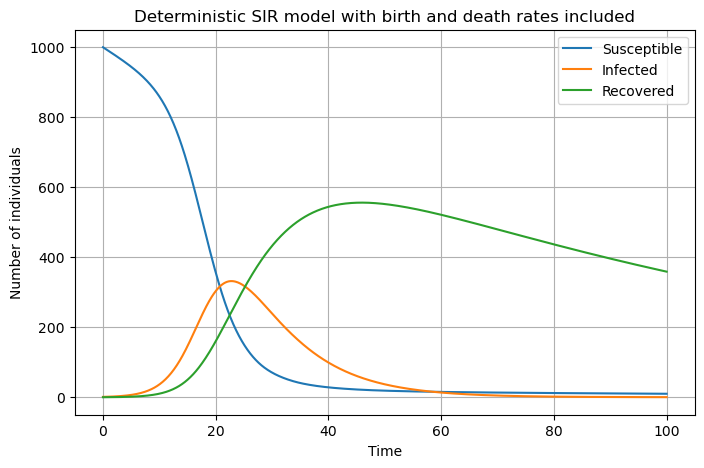

In [ ]:
# Parameters
N = 1000 # Total population size
beta = 0.5
gamma = 0.1
Lambda = 0.01 # birth rate
mu = 0.01 # death rate
I0 = 1 # Initial number of infected
R0 = 0 # Initial number of recovered
S0 = N - I0 - R0 # Initial number of susceptible 

# Time interval
t_start = 0
t_end = 100
t_vals = np.linspace(t_start, t_end, 1000)

# SIR ODE system
def sir_ode(t, y, beta, gamma, Lambda, mu, N):
    S, I, R = y

    dSdt = Lambda - mu * S - beta/N * I * S
    dIdt = beta/N * I * S - gamma * I - mu * I
    dRdt = gamma * I - mu * R

    return (dSdt, dIdt, dRdt)

# Solve ODE system using solve_ivp (used to "Solve an initial value problem for a system of ODEs")
sol = solve_ivp(fun=sir_ode, t_span=(t_start, t_end), y0=[S0, I0, R0], args=[beta, gamma, Lambda, mu, N], t_eval=t_vals)

# Extract solution
S, I, R = sol.y

# Basic reproduction number
R0 = beta / gamma
print(f"Baisc reproduction number: {R0}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sol.t, S, label="Susceptible")
plt.plot(sol.t, I, label="Infected")
plt.plot(sol.t, R, label="Recovered")
plt.xlabel("Time")
plt.ylabel("Number of individuals")
plt.title("Deterministic SIR model with birth and death rates included")
plt.legend()
plt.grid()
plt.show()